In [2]:
import os
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import scipy
import torch
from sklearn import metrics

import pickle
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
import itertools
from tqdm import tqdm

warnings.filterwarnings('ignore')

/admin/software/anaconda/1.11.1/envs/jupyter/bin/python


In [3]:
%matplotlib inline

In [4]:
def get_starts(chrom_list, step = 5e4):
    startl = [] #hold all the start positions across all chromosomes
    chroml = [] #hold the chromosome label corresponding to each start
    for chrom in chrom_list:
        chrom = 'chr{}'.format(chrom)
        cur_starts = list(np.arange(start_dict[chrom],end_dict[chrom]-5000000, step).astype(int))
        startl = startl + cur_starts
        chroml = chroml + list(np.repeat(chrom, len(cur_starts)))
    return startl, chroml

def get_visualization(y_hat_list,y_true_list,avg_stripes = False):
    y_hat_list_reshaped = np.concatenate([x.reshape(1,-1) for x in y_hat_list[start_ind_origami:start_ind_origami+plot_len]], axis = 0)
    y_true_list_reshaped = np.concatenate([x.reshape(1,-1) for x in y_true_list[start_ind_origami:start_ind_origami+plot_len]], axis = 0)
    mat = []
    mat_ytrue = []
    for i in range(plot_len):
        mat.append(np.insert(np.zeros(plot_len), i, y_hat_list_reshaped[i]))
        mat_ytrue.append(np.insert(np.zeros(plot_len), i, y_true_list_reshaped[i].clip(-16,16)))
    if avg_stripes:
        summed = (pd.DataFrame(np.array(mat)).reindex(np.arange(-1*pred_len,plot_len+1,1)).fillna(0).iloc[0:plot_len+pred_len+1,0:plot_len+pred_len+1].values+pd.DataFrame(np.array(mat)).reindex(
        np.arange(-1*pred_len,plot_len+1,1)).fillna(0).T.iloc[0:plot_len+pred_len+1,0:plot_len+pred_len+1].values)/2
    else:
        summed = pd.DataFrame(np.array(mat)).reindex(np.arange(-1*pred_len,plot_len+1,1)).fillna(0).T.iloc[0:plot_len+pred_len+1,0:plot_len+pred_len+1].values
                  
    comb = np.zeros((summed.shape[0],summed.shape[0]))
    # keep upper trangular part for vis
    comb[np.triu_indices(comb.shape[0])[0],np.triu_indices(comb.shape[0])[1]] = (summed[np.triu_indices(comb.shape[0])[0],
                                                    np.triu_indices(comb.shape[0])[1]])
    # bottom triangular part is 0
    comb[np.tril_indices(comb.shape[0],k = -1)[0],np.tril_indices(comb.shape[0],k = -1)[1]] = 0

    return comb

def kth_diag_indices(a, k):
    rows, cols = np.diag_indices_from(a)
    if k < 0:
        return rows[-k:], cols[:k]
    elif k > 0:
        return rows[:-k], cols[k:]
    else:
        return rows, cols
    
def get_combined_yhat(y_hat_list, start_ind, end_ind, offset = 200, avg_stripe = False): 
    pred_len = 200
    y_hat_list_reshaped = np.concatenate([x.reshape(1,-1) for x in y_hat_list[start_ind:end_ind]], axis = 0)
    chrom_length = y_hat_list_reshaped.shape[0]
    mat = []

    for i in tqdm(range(chrom_length)):
        mat.append(np.insert(np.zeros(chrom_length+offset+1), i, np.insert(y_hat_list_reshaped[i],pred_len,0)))
    summed = pd.DataFrame(
    np.array(mat)).reindex(np.arange(-1*pred_len,chrom_length,1)
        ).fillna(0).T.iloc[0:chrom_length+pred_len,0:chrom_length+pred_len].values
    
    if avg_stripe:
        summed = (pd.DataFrame(np.array(mat)).reindex(np.arange(-1*pred_len,chrom_length,1)
                ).fillna(0).iloc[0:chrom_length+pred_len,0:chrom_length+pred_len].values+pd.DataFrame(
            np.array(mat)).reindex(np.arange(-1*pred_len,chrom_length,1)
                ).fillna(0).T.iloc[0:chrom_length+pred_len,0:chrom_length+pred_len].values)/2
    # if in inference use offset -2MB    
    summed = summed[200:-200,200:-200] # remove padded region
    # if in inference use offset 0
    #summed = summed[:-200,:-200] # remove padded region

    return summed

def get_metacell_profile(tile_dict, nbrs):
    metacell_tile_dict = {}
    metacell = nbrs
    for chrom in list(tile_dict.keys()):
        metacell_tile_dict[chrom] = (scipy.sparse.csr_matrix(metacell) * tile_dict[chrom])
    return metacell_tile_dict 

def cpu_jaccard_vstripe(x):
    size = x.shape[1]
    eps=1e-8
    i = 2

    x = torch.where(x>0.0, torch.tensor([1.0]), torch.tensor([0.0]))
    num = torch.mm(x, x.transpose(0,1))
    
    x = torch.where(x==0.0, torch.tensor([1.0]), torch.tensor([0.0]))
    denom = torch.mm(x, x.transpose(0,1))
    denom = size - denom

    num = torch.div(num, torch.max(denom, eps * torch.ones_like(denom)))
    
    return num

def cpu_batch_corcoeff_vstripe(x):
    c = cpu_jaccard_vstripe(x.permute(1,0))
    c[c != c] = 0
    return c

def get_preds(chroms, path):

    y_z_hat_list = []
    tmp = []
    for chrom in chroms:
        tmp.append(np.load(path + '{}.npz'.format(chrom))['arr_0'])
    tmp = np.concatenate([y for y in tmp], axis = 0)
    y_z_hat_list.append(tmp)
    y_z_hat_list = np.concatenate([np.expand_dims(y,1) for y in y_z_hat_list], axis = 1)

    return y_z_hat_list

def pcolormesh_45deg(C,vmax,vmin):
    n = C.shape[0]
    # create rotation/scaling matrix
    t = np.array([[1,0.5],[-1,0.5]])
    # create coordinate matrix and transform it
    A = np.dot(np.array([(i[1],i[0]) for i in itertools.product(range(n,-1,-1),range(0,n+1,1))]),t)
    # plot
    img = plt.pcolormesh(A[:,1].reshape(n+1,n+1),A[:,0].reshape(n+1,n+1),np.flipud(C),
                  cmap = 'RdBu_r',
                         vmax = vmax, vmin = vmin
                        )
    return img
    

In [66]:
ct = 'BRCA-14AD76EE-12F9-40B3-8DCD-4A256E02CF8D-X002-S03-B1-T1_H3K27ac'
#BRCA-14AD76EE-12F9-40B3-8DCD-4A256E02CF8D-X002-S03-B1-T1_H3K27ac
#BRCA-8D1E6006-85CB-484A-8B5C-30766D90137B-X005-S02-B1-T1_H3K27ac
#BRCA-C147AAD5-A8F1-41D5-8709-21820BE50902-X005-S01-B1-T1_H3K27ac
#BRCA-DD69EDE9-142D-46E2-AA06-58D07D3230FB-X002-S04-B1-T1_H3K27ac
ct2 = 'BRCA_14AD76EE_12F9_40B3_8DCD_4A256E02CF8D_X003_S02_B1_T1'
#BRCA_14AD76EE_12F9_40B3_8DCD_4A256E02CF8D_X003_S02_B1_T1
#BRCA_8D1E6006_85CB_484A_8B5C_30766D90137B_X001_S01_B1_T1
#BRCA_C147AAD5_A8F1_41D5_8709_21820BE50902_X008_S02_B1_T1
#BRCA_DD69EDE9_142D_46E2_AA06_58D07D3230FB_X014_S08_B1_T1
genome = 'hg38'
mod = 'chromafold_CTCFmotif'

In [69]:
# Load Hi-C data for evaluation
zscore_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/"
    f"{ct}/zvalue/{ct}_hic_zscore_dict.p"
)

pval_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/"
    f"{ct}/qvalue/{ct}_hic_qvalue_dict.p"
)

with open(zscore_path, "rb") as f:
    hicdc = pickle.load(f)

with open(pval_path, "rb") as f:
    pval = pickle.load(f)
    
#hicdc = pickle.load(open("/data1/lesliec/carolw/projects/chromafold/preprocess/GBM-chan/hichip/{}/zvalue/{}_hic_zscore_dict.p".format(ct), "rb"))
#pval = pickle.load(open("/data1/lesliec/carolw/projects/chromafold/preprocess/GBM-chan/hichip/{}/qvalue/{}_hic_qvalue_dict.p".format(ct), "rb"))


In [68]:
# Load input data for visualization
ctcf_motif = pickle.load(open("/data1/lesliec/carolw/repos/ChromaFold/{}_ctcf_motif_score.p".format(genome), 'rb'))
atac = pickle.load(open("/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/atac/{}_tile_pbulk_50bp_dict.p".format(ct2), 'rb'))
scatac = pickle.load(open("/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/atac/{}_tile_500bp_dict.p".format(ct2), 'rb'))
metacell_path = pd.read_csv('/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/atac/{}_metacell_mask.csv'.format(ct2), index_col= 0).values
scatac = get_metacell_profile(scatac, metacell_path)


In [70]:
chrom = list(scatac.keys())[0]
print("Tile matrix shape:", scatac[chrom].shape)


Tile matrix shape: (43, 117236)


# Quantitative Evaluation

In [71]:
chrom = '6'

In [72]:
print(type(hicdc['chr6']))

<class 'scipy.sparse._csr.csr_matrix'>


In [73]:
hicdc_mat = hicdc['chr{}'.format(chrom)].toarray()
hicdc_pval_mat = pval['chr{}'.format(chrom)].toarray()

In [74]:
# Get predictions
y_hat = get_preds(
    [chrom],
    f"/data1/lesliec/carolw/projects/chromafold/predictions/BRCA-chan/{ct2}/prediction_{ct2}_chr"
)



In [75]:
# Evaluate
pearson_list = {}
spearman_list = {}
roc_list = {}
prc_list = {}

# Get ground-truth Hi-C data
# Removes last 501 bins from both dimensions, clip extreme zscore
print("hicdc_mat: ", hicdc_mat.shape)
true_mat = hicdc_mat[:-501,:-501].clip(-16,16)  
#true_mat = hicdc_mat[200:-501,200:-501].clip(-16,16) # chrom start offset by 2MB
print("true_mat:",true_mat.shape)
min_len = len(np.diag(true_mat,199)) # Compute shortest diagonal length
print("min_len:",min_len)

# Significant interaction analysis
percentile_cutoff = 90 # Zscore percentile cutoff for significant interactions
bin_true = np.concatenate([np.diag(true_mat,i)[0:min_len] for i in range(1,200)]).reshape(-1, min_len)
bin_mask = (bin_true.sum(0) >= np.percentile(bin_true.sum(0),1)) #mask for low-mappability regions
print("bin_mask length:", len(bin_mask))
all_zval = np.concatenate([np.diag(true_mat,i)[0:min_len] for i in range(1,200)])
zval_cutoff = np.percentile(all_zval, percentile_cutoff)
bin_zval = all_zval > zval_cutoff
print('Positive class proportion: {}'.format(bin_zval.sum()/bin_zval.shape[0]))
print('Zval cutoff: {}'.format(zval_cutoff))

# Get processed predictions
pred_mat = get_combined_yhat(y_hat[:,0,:], start_ind = 0, end_ind = y_hat.shape[0], avg_stripe=True)
print("pred_mat:", pred_mat.shape)
print("diag lengths:")
for i in range(1,5):
    print(i, len(np.diag(true_mat,i)), len(np.diag(pred_mat,i)))
    
pearson_list[mod] = []
spearman_list[mod] = []
roc_list[mod] = []
prc_list[mod] = []

# fixed to aovid min_len exceed pred_mat index
for i in range(1,200):
    #true_diag = np.diag(true_mat, i)
    #pred_diag = np.diag(pred_mat, i)
    #diag_len = min(len(true_diag), len(pred_diag), len(bin_mask))
    #a = true_diag[:diag_len][bin_mask[:diag_len]]
    #b = pred_diag[:diag_len][bin_mask[:diag_len]]
    #p = a > zval_cutoff
    
    a = np.diag(true_mat,i)[0:min_len][bin_mask]
    b = np.diag(pred_mat,i)[0:min_len][bin_mask]
    p = np.diag(true_mat,i)[0:min_len][bin_mask] > zval_cutoff
    
    fpr, tpr, thresholds = metrics.roc_curve(p.astype(int), b)
    precision, recall, thresholds = metrics.precision_recall_curve(p.astype(int), b)
    pearson_list[mod].append(scipy.stats.pearsonr(a,b)[0])    
    spearman_list[mod].append(scipy.stats.spearmanr(a,b)[0])    
    roc_list[mod].append(metrics.auc(fpr, tpr))
    prc_list[mod].append(metrics.auc(recall, precision))
    


hicdc_mat:  (17075, 17075)
true_mat: (16574, 16574)
min_len: 16375
bin_mask length: 16375
Positive class proportion: 0.10000015343895048
Zval cutoff: 1.8398122400000003


100%|██████████| 16780/16780 [00:00<00:00, 17760.07it/s]


pred_mat: (16580, 16580)
diag lengths:
1 16573 16579
2 16572 16578
3 16571 16577
4 16570 16576


(0.0, 1.0)

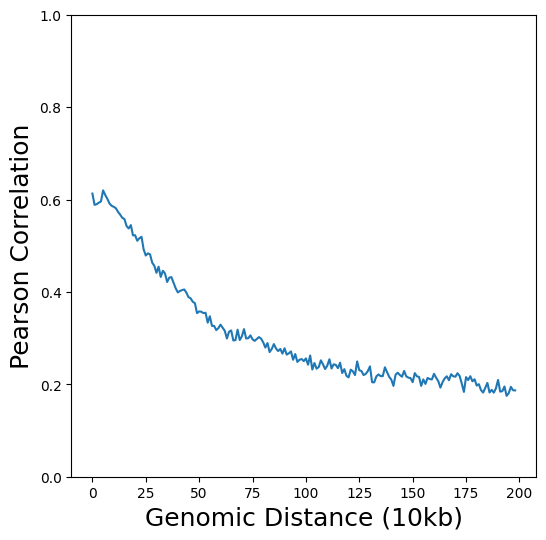

In [76]:
plt.rcParams['figure.figsize'] = 6,6
plt.plot(pearson_list[mod], label = mod)
# plt.legend()
plt.ylabel('Pearson Correlation', fontsize = 18)
plt.xlabel('Genomic Distance (10kb)', fontsize = 18)
plt.ylim(0,1)

(0.0, 1.0)

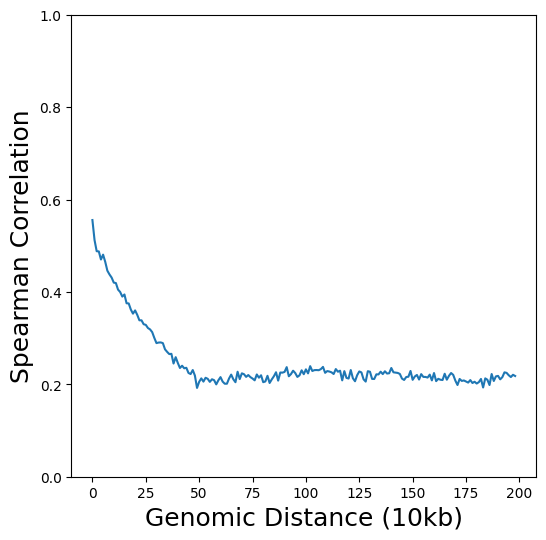

In [77]:
plt.rcParams['figure.figsize'] = 6,6
plt.plot(spearman_list[mod], label = mod)
# plt.legend()
plt.ylabel('Spearman Correlation', fontsize = 18)
plt.xlabel('Genomic Distance (10kb)', fontsize = 18)
plt.ylim(0,1)

(0.0, 1.0)

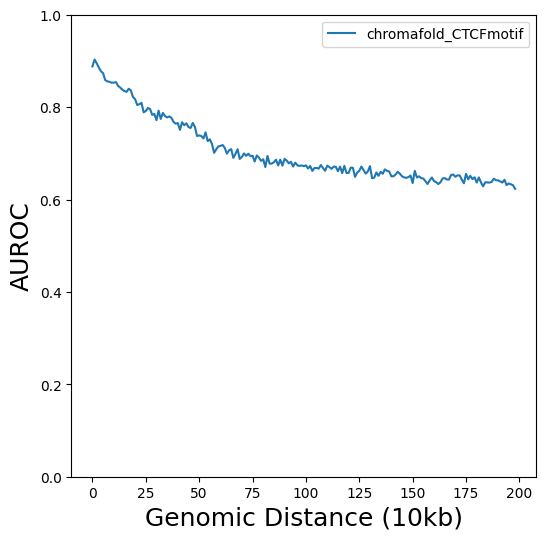

In [78]:
plt.rcParams['figure.figsize'] = 6,6
plt.plot(roc_list[mod], label = mod)
plt.legend()
plt.ylabel('AUROC', fontsize = 18)
plt.xlabel('Genomic Distance (10kb)', fontsize = 18)
plt.ylim(0,1)

(0.0, 1.0)

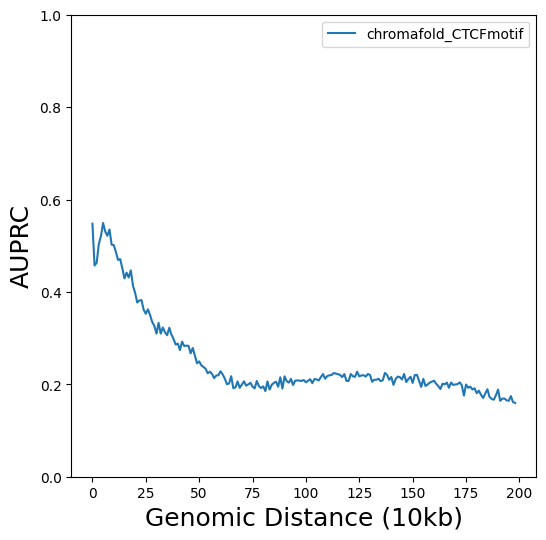

In [79]:
plt.rcParams['figure.figsize'] = 6,6
plt.plot(prc_list[mod], label = mod)
plt.legend()
plt.ylabel('AUPRC', fontsize = 18)
plt.xlabel('Genomic Distance (10kb)', fontsize = 18)
plt.ylim(0,1)

# Visualize

In [80]:
pred_mat = get_combined_yhat(y_hat[:,0,:], start_ind = 0, end_ind = y_hat.shape[0], avg_stripe=True)


100%|██████████| 16780/16780 [00:00<00:00, 17511.33it/s]


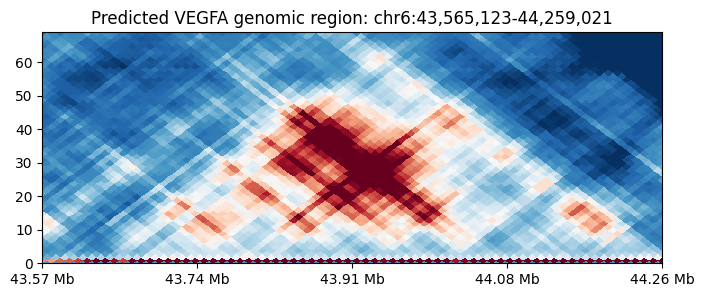

In [81]:
# Added code
resolution = 10_000
start_bp = 43_565_123 #57_770_000
end_bp   = 44_259_021 #59_770_000

zoom_start_bin = start_bp // resolution
zoom_end_bin   = end_bp // resolution

#define larger plotting region
pad_bp = 1_000_000
plot_start_bp = start_bp - pad_bp
plot_end_bp   = end_bp + pad_bp

plot_start_bin = plot_start_bp // resolution
plot_end_bin   = plot_end_bp // resolution

#compute zoom coordinates relative to 
zoom_start = zoom_start_bin - plot_start_bin
zoom_end   = zoom_end_bin   - plot_start_bin

# Number of ticks you want
n_ticks = 5

# Tick positions in matrix coordinates
ticks = np.linspace(zoom_start, zoom_end, n_ticks)

# Convert bins → genomic coordinates
tick_labels = [
    f"{(plot_start_bp + int(t)*resolution)/1e6:.2f} Mb"
    for t in ticks
]

#extract larger hic region
region = pred_mat[plot_start_bin:plot_end_bin,
                  plot_start_bin:plot_end_bin]

region = np.triu(region)


plt.rcParams['figure.figsize'] = (8,3)
img = pcolormesh_45deg(region, 4, -1)
# zoom in
plt.xlim(zoom_start, zoom_end)
plt.ylim(0, zoom_end - zoom_start)
plt.xticks(ticks, tick_labels)
plt.title("Predicted VEGFA genomic region: chr6:43,565,123-44,259,021")
plt.show()



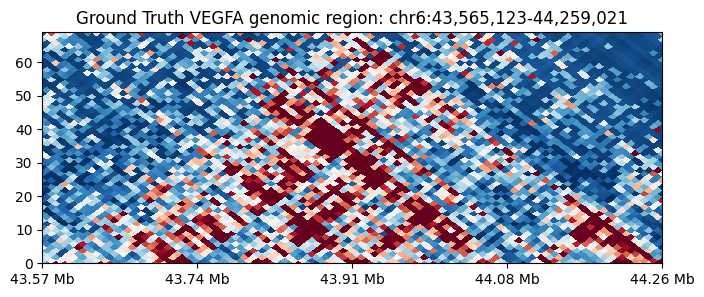

In [82]:
# Added code
#extract larger hic region
region = hicdc_mat[plot_start_bin:plot_end_bin,
                  plot_start_bin:plot_end_bin]

region = np.triu(region)


plt.rcParams['figure.figsize'] = (8,3)
img = pcolormesh_45deg(region, 4, -1)
# zoom in
plt.xlim(zoom_start, zoom_end)
plt.ylim(0, zoom_end - zoom_start)
plt.xticks(ticks, tick_labels)
plt.title("Ground Truth VEGFA genomic region: chr6:43,565,123-44,259,021")
plt.show()

In [83]:
# Added code
#VEGFA genomic region: chr6:43,565,123-44,259,021
#resolution = 10_000
#start_bp = 42_565_123 
#end_bp   = 45_259_021 
#ext_start_bp = start_bp - 1_000_000 # extend 1MB
#ext_end_bp   = start_bp + 1_000_000 
#bin in HiC resolution
#start_bin = ext_start_bp // resolution #4257
#end_bin   = ext_end_bp   = start_bp + 1_000_000  // resolution #4523

start_bin = 4256  #5677
end_bin = 4525 #6077

#convert to scATAC resolution
tmp = cpu_batch_corcoeff_vstripe(torch.tensor(scatac['chr{}'.format(chrom)][:, (start_bin)*20 : (end_bin)*20].toarray()))
#convert back to HIC resolution
tmp = tmp.reshape(tmp.shape[0]//20, 20, -1).mean(axis=1).reshape(-1, tmp.shape[1]//20, 20).mean(axis=2)


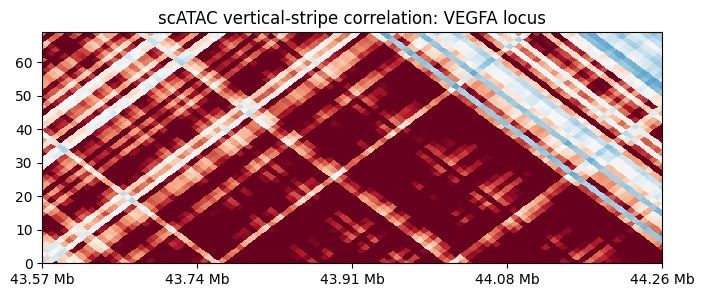

In [84]:
n_ticks = 5
#tick_start = 1_000_000 // resolution #100
#tick_end = (end_bin - start_bin) - 1_000_000 // resolution #166
ticks = np.linspace(100, 169, n_ticks)  # bin indices along matrix
tick_labels = [f"{(42_565_123 + int(t)*10_000)/1e6:.2f} Mb" for t in ticks]
#ticks = np.linspace(100, 300, n_ticks)  # bin indices along matrix
#tick_labels = [f"{(56_770_000 + int(t)*10_000)/1e6:.2f} Mb" for t in ticks]

plt.rcParams['figure.figsize'] = 8, 3
img = pcolormesh_45deg(tmp, vmax = 0.5, vmin = 0)
plt.xlim(100,169)
plt.ylim(0,zoom_end - zoom_start)
plt.xticks(ticks, tick_labels)
plt.title("scATAC vertical-stripe correlation: VEGFA locus")
plt.show()


Text(0, 0.5, 'CTCF motif score')

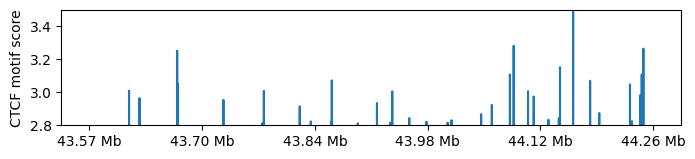

In [85]:
resolution =10_000

start_bin = 43_565_123 // resolution
end_bin   = 44_259_021 //resolution

n_ticks = 6
num_bin = (end_bin-start_bin)*200
ticks = np.linspace(0, num_bin, n_ticks)  # bin indices along matrix
tick_labels = [
    f"{(43_565_123 + (t / 200) * resolution) / 1e6:.2f} Mb"
    for t in ticks
]

plt.rcParams['figure.figsize'] = 8, 1.5
plt.plot(ctcf_motif['chr{}'.format(chrom)].toarray()[0][(start_bin)*200 : (end_bin)*200])
plt.xticks(ticks, tick_labels)
plt.ylim(2.8,3.5)
plt.ylabel('CTCF motif score')


Text(0, 0.5, 'ATAC-seq signal')

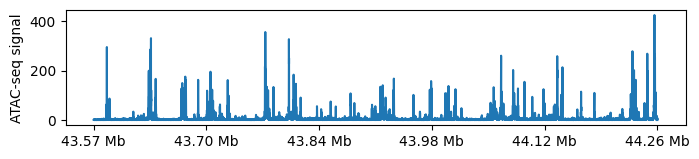

In [86]:
plt.plot(atac['chr{}'.format(chrom)][(start_bin)*200 : (end_bin)*200])
plt.xticks(ticks, tick_labels)
#plt.xlim(0, 50000)
# plt.ylim(2.8,3.5)
plt.ylabel('ATAC-seq signal')

In [38]:
start = 5477 #2000


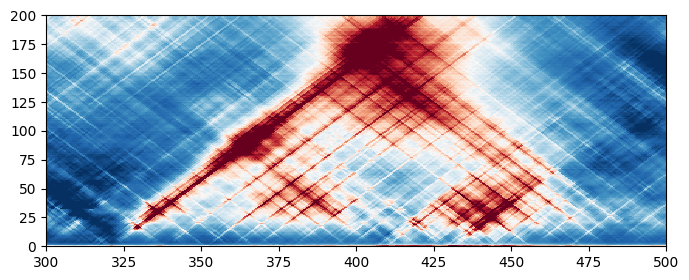

In [39]:
# Prediction
plt.rcParams['figure.figsize'] = 8, 3
img = pcolormesh_45deg(np.triu(pred_mat[start:start+700,start:start+700]), 4,-1)
plt.ylim(0,200)
plt.xlim(300,500)
plt.show()


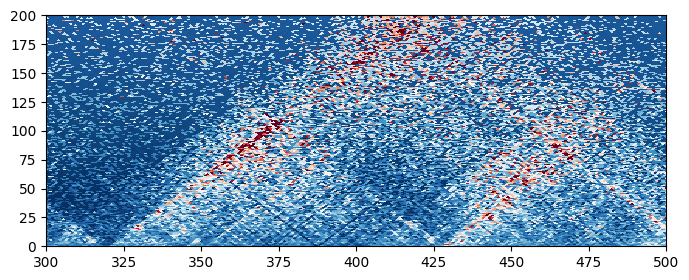

In [45]:
# Ground Truth
img = pcolormesh_45deg(np.triu(hicdc_mat[start+200:start+900,start+200:start+900]), 7,-1)
plt.ylim(0,200)
plt.xlim(300,500)
plt.show()

In [41]:
# how similarly two genomic loci are accessbile across single cells
# open together / close together
# 20 ATAC bins = 1 Hi-C bin
tmp = cpu_batch_corcoeff_vstripe(torch.tensor(scatac['chr{}'.format(chrom)][:, (start)*20 : (start+700)*20].toarray()))
tmp = tmp.reshape(tmp.shape[0]//20, 20, -1).mean(axis=1).reshape(-1, tmp.shape[1]//20, 20).mean(axis=2)



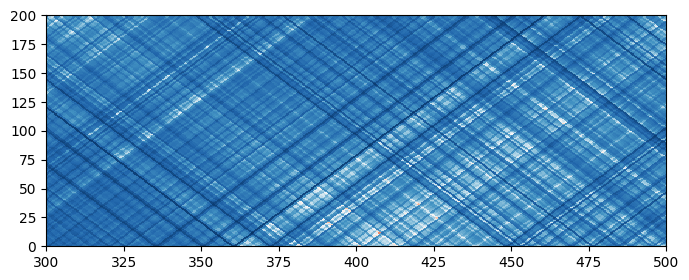

In [42]:
# Jaccard similarity
plt.rcParams['figure.figsize'] = 8, 3
img = pcolormesh_45deg(tmp, vmax = 0.5, vmin = 0)
plt.ylim(0,200)
plt.xlim(300,500)
plt.show()

In [87]:
import coolbox
from coolbox.api import *
frame = XAxis() + GTF("/data1/lesliec/carolw/genome/hg38/gencode.v49.annotation.gtf", 
                      length_ratio_thresh = 0.005, fontsize = 32) + TrackHeight(4)


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.
[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


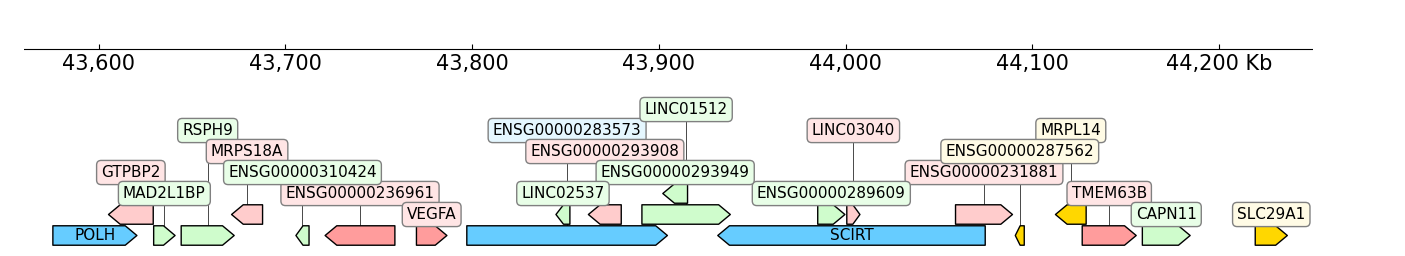

In [28]:
TEST_RANGE = "chr{}:{}-{}".format(chrom, (start_bin)*200*50, (end_bin)*200*50)

frame.plot(TEST_RANGE)


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.
[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


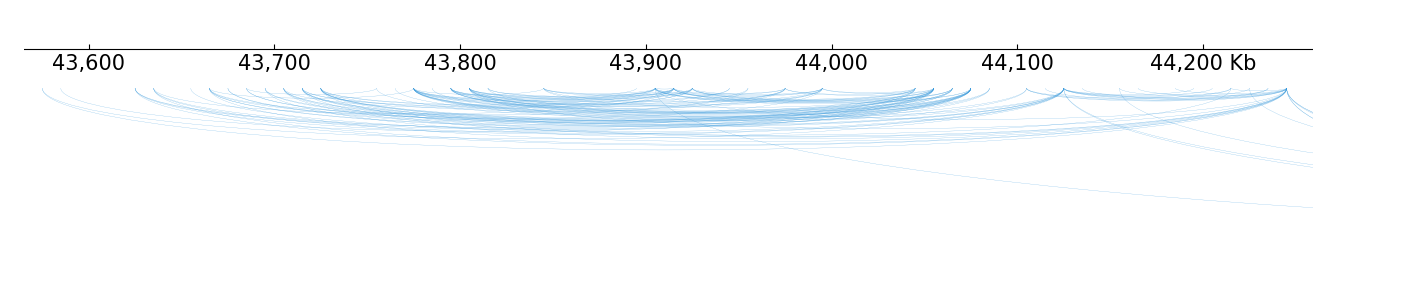

In [92]:
start  = 43_565_123 
end   = 44_259_021 

ct="BRCA-14AD76EE-12F9-40B3-8DCD-4A256E02CF8D-X002-S03-B1-T1_H3K27ac"
peak_dir= f"/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/{ct}"
frame = XAxis() + Arcs(f"{peak_dir}/{ct}_hg38_10kb_GATC_GANTC_FDR_05_norm.bedpe", line_width = 0.15) + Inverted()+ TrackHeight(5)
frame.plot(f"chr{chrom}:{start}-{end}")


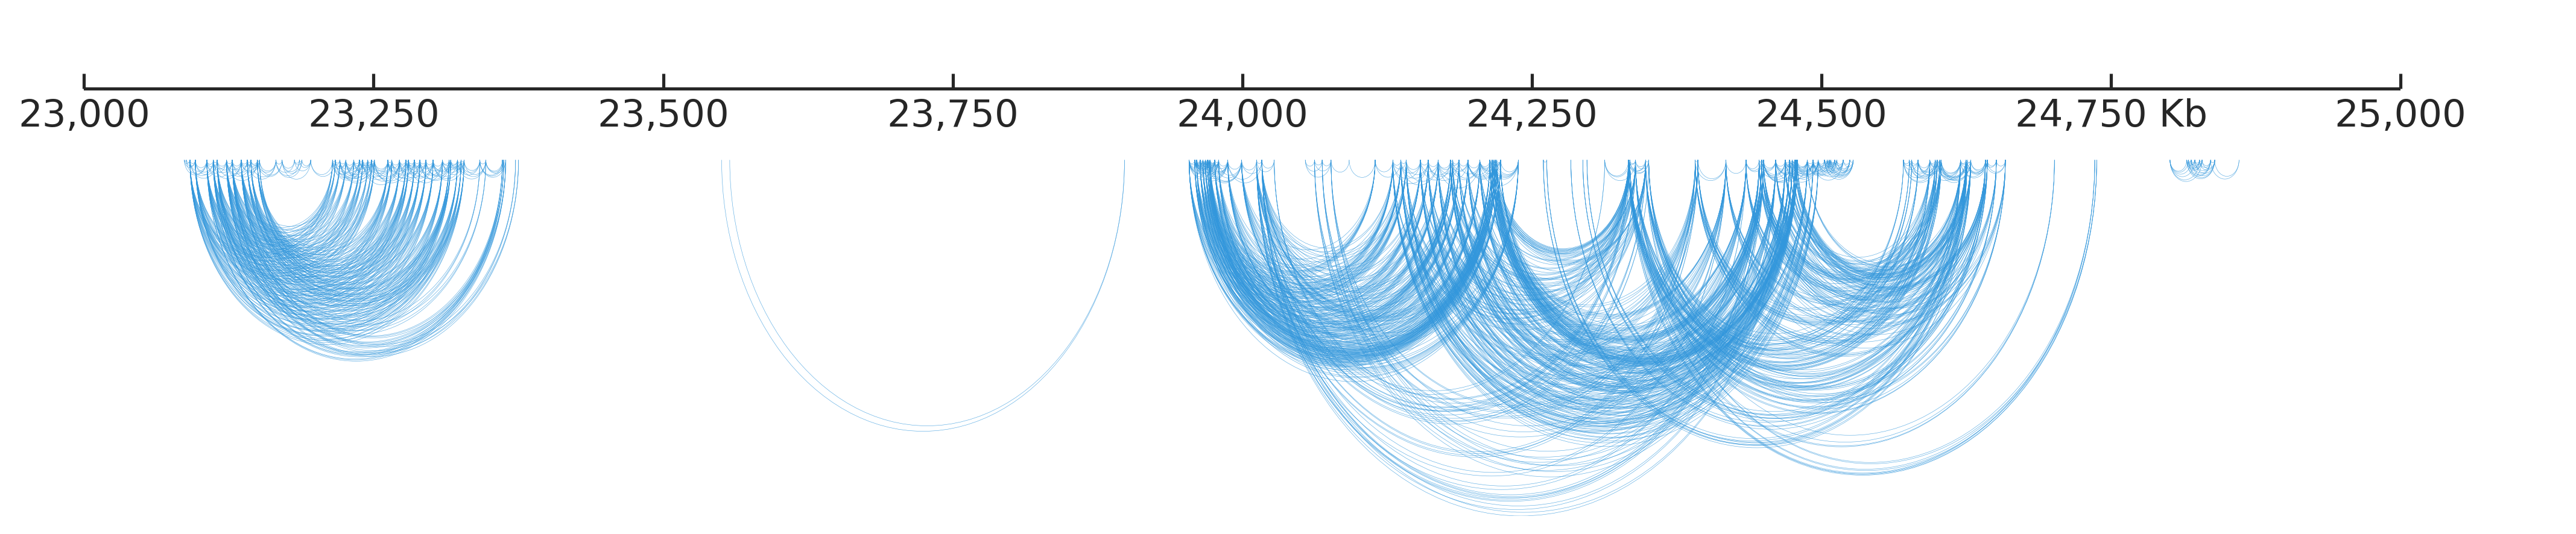

In [97]:
frame = XAxis() + Arcs("./peak_interactions/bedpe/{}_chromafold.bedpe".format(ct), line_width = 0.15) + Inverted()+ TrackHeight(5)
frame.plot("chr16:{}-{}".format(((start_ind)*20000+40000)*50 , ((start_ind)*20000+40000+40000)*50))
